<a href="https://colab.research.google.com/github/AlenaFisher/CS234/blob/master/Fisher_Alena_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Alena Fisher  
CSCI 460 - Introduction to Applied Machine Learning  
Final Project 2026  
05/03/2026

In [ ]:
# Importing libraries
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.decomposition import PCA

In [ ]:
# Mounting Google drive
from google.colab import drive
drive.mount('/content/drive')
%cd /gdrive

Mounted at /content/drive
[Errno 2] No such file or directory: '/gdrive'
/content


In [ ]:
# Changing working directory and verifying that the files are present
!pwd
%cd /content/drive/MyDrive/CSCI_460 Project
!ls

/content
/content/drive/MyDrive/CSCI_460 Project
aps_failure_test_set.csv      Fisher_Alena_Project.ipynb
aps_failure_training_set.csv  model_results.csv


1. Exploratory Data Analysis (EDA)

In [ ]:
"""
Load the APS datasets for training and testing. The first 20 contain data
that is not needed (descriptions, attribute information) rather than observational data.
The first 20 rows are skipped to ensure that only the relevant data is considered for the models.
"""

df_training = pd.read_csv("aps_failure_training_set.csv", skiprows=20)
df_test = pd.read_csv("aps_failure_test_set.csv", skiprows=20)

In [ ]:
"""
Replace all occurences of the string "na" with Numpy NaN values. Missing
values in this dataset are represented as the string "na"; converting them
ensures compatability with all built-in pandas functions for proper preprocessing.
"""
df_training.replace("na", np.nan, inplace=True)
df_test.replace("na", np.nan, inplace=True)

In [ ]:
"""
Convert all columns to applicable data types. Some columns are represented
as strings; converting each column to numeric data types allows for proper preprocessing
and usage in the models.
"""
df_training = df_training.apply(pd.to_numeric, errors='ignore')
df_test = df_test.apply(pd.to_numeric, errors='ignore')

/tmp/ipykernel_2274/3413422782.py:6: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_training = df_training.apply(pd.to_numeric, errors='ignore')
/tmp/ipykernel_2274/3413422782.py:7: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_test = df_test.apply(pd.to_numeric, errors='ignore')


Basic Dataset Overview

In [ ]:
# Display the first few rows of the dataset.
df_training.head()

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,...,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,neg,33058,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,...,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,neg,41040,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,...,277378.0,159812.0,423992.0,409564.0,320746.0,158022.0,95128.0,514.0,0.0,0.0
3,neg,12,0.0,7.000000e+01,66.0,0.0,10.0,0.0,0.0,0.0,...,240.0,46.0,58.0,44.0,10.0,0.0,0.0,0.0,4.0,32.0
4,neg,60874,NaN,1.368000e+03,458.0,0.0,0.0,0.0,0.0,0.0,...,622012.0,229790.0,405298.0,347188.0,286954.0,311560.0,433954.0,1218.0,0.0,0.0


In [ ]:
# Check the dimensions of the dataset (rows, columns)
df_training.shape

(60000, 171)

In [ ]:
# Display detailed information about the dataset
df_training.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 171 entries, class to eg_000
dtypes: float64(169), int64(1), object(1)
memory usage: 78.3+ MB


In [ ]:
# Count the number of unique values in each column
df_training.nunique()

,0
class,2
aa_000,22095
ab_000,29
ac_000,2061
ad_000,1886
...,...
ee_007,30469
ee_008,24213
ee_009,9724
ef_000,28


In [ ]:
# Generate descriptive statistics for the features
df_training.describe()

,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
count,6.000000e+04,13671.000000,5.666500e+04,4.513900e+04,57500.000000,57500.000000,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,...,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,57276.000000,57277.000000
mean,5.933650e+04,0.713189,3.560143e+08,1.906206e+05,6.819130,11.006817,2.216364e+02,9.757223e+02,8.606015e+03,8.859128e+04,...,4.454897e+05,2.111264e+05,4.457343e+05,3.939462e+05,3.330582e+05,3.462714e+05,1.387300e+05,8.388915e+03,0.090579,0.212756
std,1.454301e+05,3.478962,7.948749e+08,4.040441e+07,161.543373,209.792592,2.047846e+04,3.420053e+04,1.503220e+05,7.617312e+05,...,1.155540e+06,5.433188e+05,1.168314e+06,1.121044e+06,1.069160e+06,1.728056e+06,4.495100e+05,4.747043e+04,4.368855,8.830641
min,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,8.340000e+02,0.000000,1.600000e+01,2.400000e+01,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,2.936000e+03,1.166000e+03,2.700000e+03,3.584000e+03,5.120000e+02,1.100000e+02,0.000000e+00,0.000000e+00,0.000000,0.000000
50%,3.077600e+04,0.000000,1.520000e+02,1.260000e+02,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,2.337960e+05,1.120860e+05,2.215180e+05,1.899880e+05,9.243200e+04,4.109800e+04,3.812000e+03,0.000000e+00,0.000000,0.000000
75%,4.866800e+04,0.000000,9.640000e+02,4.300000e+02,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,4.383960e+05,2.182320e+05,4.666140e+05,4.032220e+05,2.750940e+05,1.678140e+05,1.397240e+05,2.028000e+03,0.000000,0.000000
max,2.746564e+06,204.000000,2.130707e+09,8.584298e+09,21050.000000,20070.000000,3.376892e+06,4.109372e+06,1.055286e+07,6.340207e+07,...,7.793393e+07,3.775839e+07,9.715238e+07,5.743524e+07,3.160781e+07,1.195801e+08,1.926740e+07,3.810078e+06,482.000000,1146.000000


Target Variable Distribution

In [ ]:
# Count the number of instances in each class (target variable)
df_training['class'].value_counts()

,count
class,
neg,59000
pos,1000


Visualization

<Axes: xlabel='class', ylabel='count'>

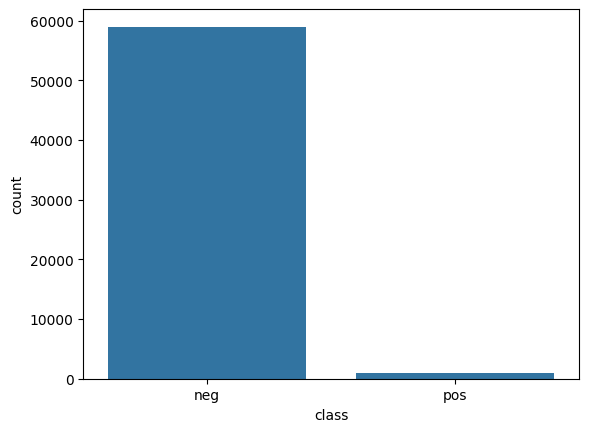

In [ ]:
# Visualize the class distribution using a count plot
sns.countplot(x='class', data=df_training)

In [ ]:
# Display the normalized class distribution (percentages)
df_training['class'].value_counts(normalize=True)

,proportion
class,
neg,0.983333
pos,0.016667


In [ ]:
# Calculate the number of missing values per feature
missing = df_training.isnull().sum()

# Filter to only include features with at least one missing value
missing = missing[missing > 0].sort_values(ascending=False)
# Display the top 20 features with the most missing values
# This helps prioritize which features may need imputation or removal
missing.head(20)

,0
br_000,49264
bq_000,48722
bp_000,47740
bo_000,46333
cr_000,46329
ab_000,46329
bn_000,44009
bm_000,39549
bl_000,27277
bk_000,23034


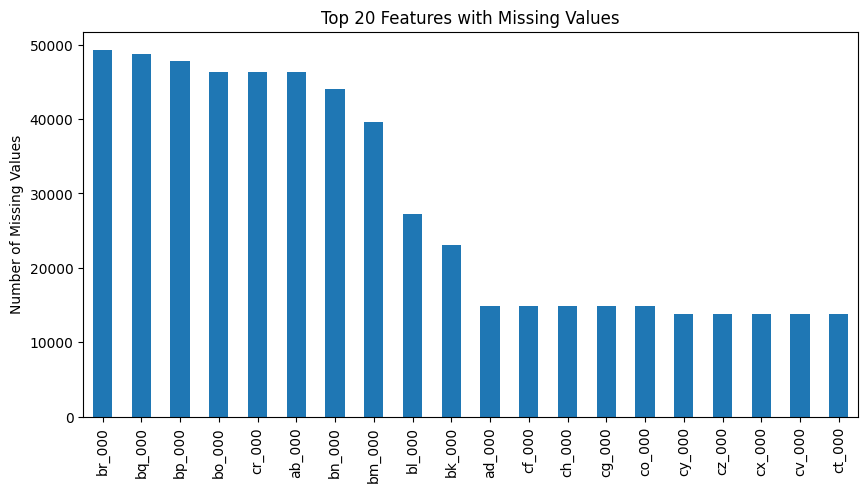

In [ ]:
# Visualization of the top 20 features with missing values.
missing.head(20).plot(kind='bar', figsize=(10,5))
plt.title("Top 20 Features with Missing Values")
plt.ylabel("Number of Missing Values")
plt.show()

Missing Value Percentage

In [ ]:
# Calculate the percentage of missing values for each feature
missing_percent = df_training.isnull().mean() * 100
# Display the top 20 features with the highest percentage of missing values
missing_percent.sort_values(ascending=False).head(20)

,0
br_000,82.106667
bq_000,81.203333
bp_000,79.566667
bo_000,77.221667
ab_000,77.215000
cr_000,77.215000
bn_000,73.348333
bm_000,65.915000
bl_000,45.461667
bk_000,38.390000


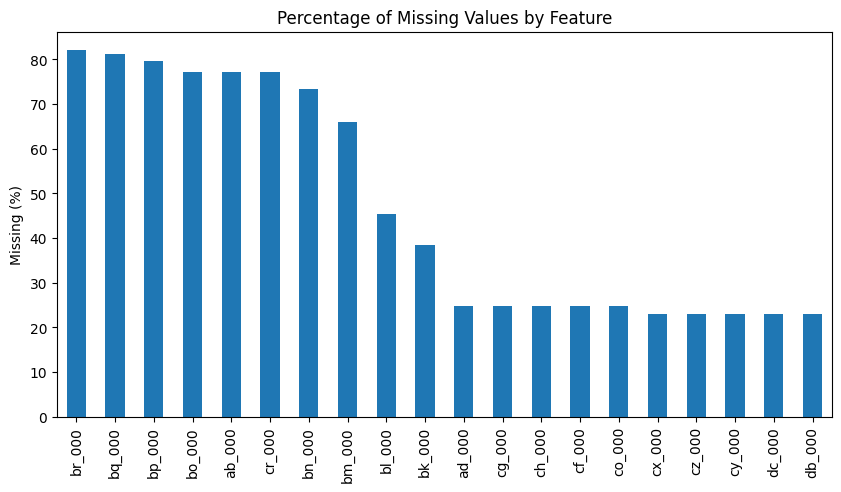

In [ ]:
# Visualization of the percentage of missing values
missing_percent.sort_values(ascending=False).head(20).plot.bar(figsize=(10,5))
plt.title("Percentage of Missing Values by Feature")
plt.ylabel("Missing (%)")
plt.show()

Feature Distribution

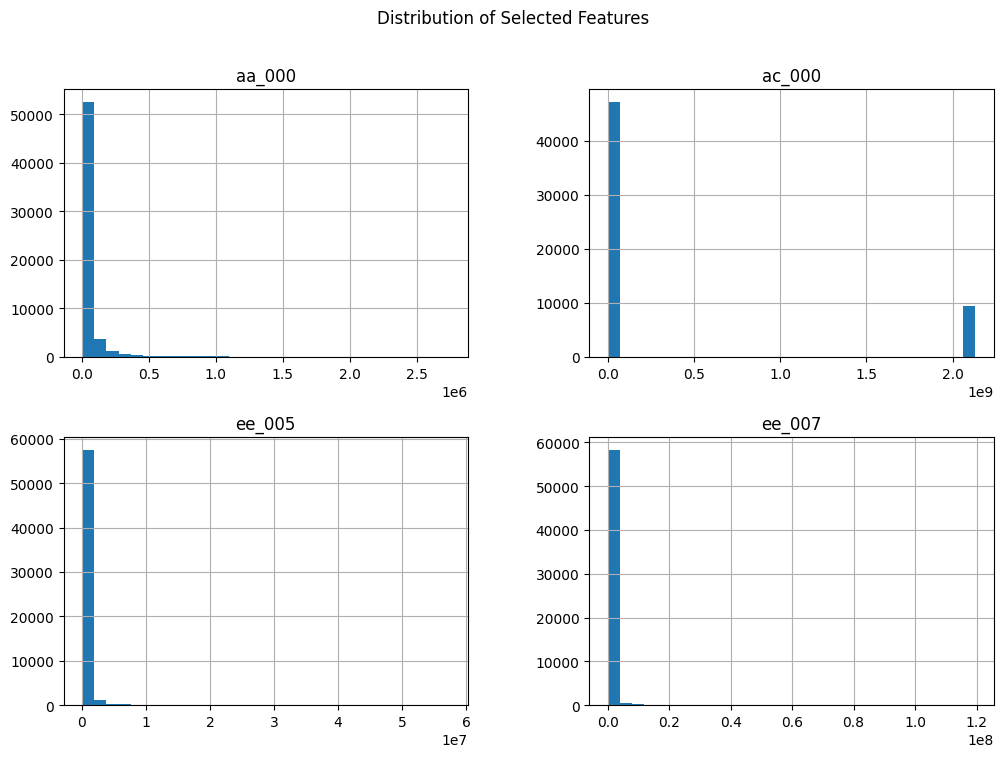

In [ ]:
# Select a subset of feature for distribution analysis
features = ["aa_000", "ac_000", "ee_005", "ee_007"]
# Selected features are converted to numerical format
df_training[features] = df_training[features].apply(pd.to_numeric, errors='coerce')
# Plot histograms
df_training[features].hist(figsize=(12,8), bins=30)
plt.suptitle("Distribution of Selected Features")
plt.show()

<Axes: xlabel='aa_000', ylabel='Count'>

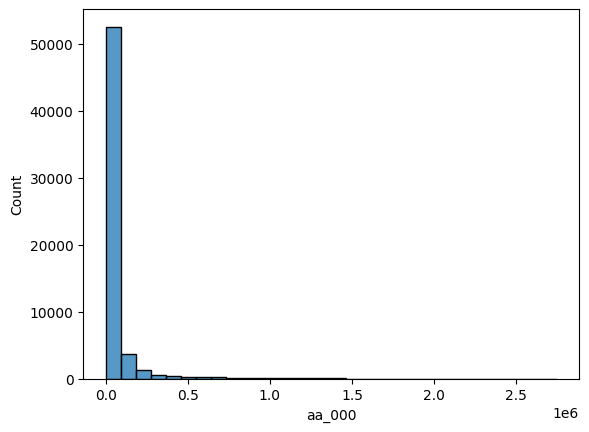

In [ ]:
# More detailed histogram for a single feature (aa_000)
sns.histplot(df_training['aa_000'], bins=30)

Boxplot Example (outliers)

<Axes: xlabel='aa_000'>

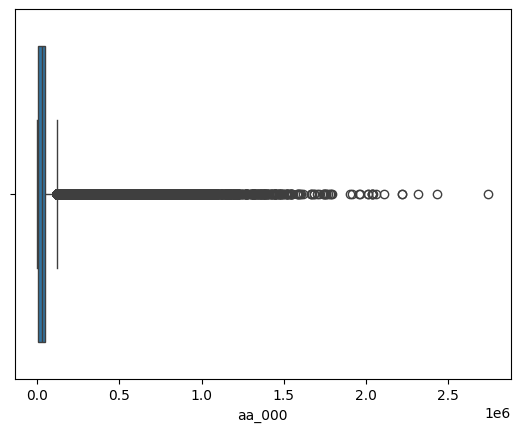

In [ ]:
# Boxplot of aa_000 to display any extreme values that could negatively
# impact model performance
sns.boxplot(x=df_training['aa_000'])

Correlation Heatmap

<Axes: >

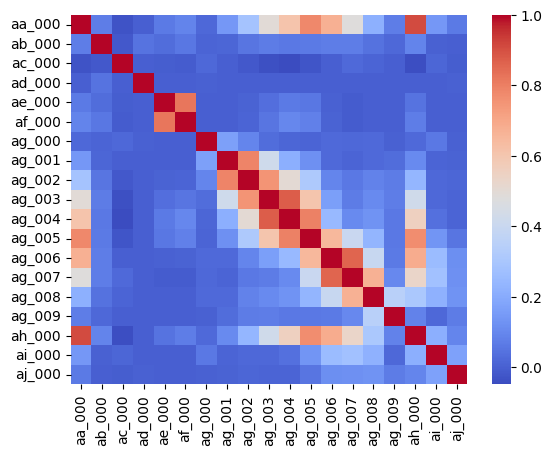

In [ ]:
# The heatmap provides a color-coded representation of correlations,
# both positive and negative
corr = df_training.iloc[:,1:20].corr()

sns.heatmap(corr, cmap='coolwarm')

Failure vs. Normal Comparison

<Axes: xlabel='class', ylabel='aa_000'>

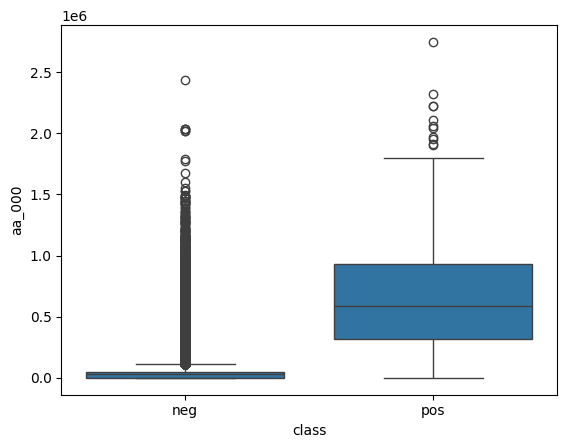

In [ ]:
# Boxplot compares the distribution of aa_000 for each class
sns.boxplot(x='class', y='aa_000', data=df_training)

Key Insights

The dataset contains 60,000 observations and 170 sensor features.
The target variable is highly imbalanced, with only 1.67% failure cases.
Many features contain large amounts of missing data, requiring imputation.
Feature distributions are highly skewed and contain outliers.
Some sensor features show moderate correlation, suggesting redundancy.
Sensor readings differ between failure and non-failure trucks, indicating predictive potential.

2. Preprocessing

In [ ]:
# Transpose the descriptive statistics for better readability
df_training.describe().T

,count,mean,std,min,25%,50%,75%,max
aa_000,60000.0,5.933650e+04,1.454301e+05,0.0,834.0,30776.0,48668.0,2.746564e+06
ab_000,13671.0,7.131885e-01,3.478962e+00,0.0,0.0,0.0,0.0,2.040000e+02
ac_000,56665.0,3.560143e+08,7.948749e+08,0.0,16.0,152.0,964.0,2.130707e+09
ad_000,45139.0,1.906206e+05,4.040441e+07,0.0,24.0,126.0,430.0,8.584298e+09
ae_000,57500.0,6.819130e+00,1.615434e+02,0.0,0.0,0.0,0.0,2.105000e+04
...,...,...,...,...,...,...,...,...
ee_007,59329.0,3.462714e+05,1.728056e+06,0.0,110.0,41098.0,167814.0,1.195801e+08
ee_008,59329.0,1.387300e+05,4.495100e+05,0.0,0.0,3812.0,139724.0,1.926740e+07
ee_009,59329.0,8.388915e+03,4.747043e+04,0.0,0.0,0.0,2028.0,3.810078e+06
ef_000,57276.0,9.057895e-02,4.368855e+00,0.0,0.0,0.0,0.0,4.820000e+02


2.1 Separate Features and Target

In [ ]:
# x is all sensor features (170 columns)
x_train = df_training.drop("class", axis=1)

# y is the target variable
y_train = df_training["class"]

In [ ]:
x_test = df_test.drop("class", axis=1)
y_test = df_test["class"]

2.2 Encode the Target Variable

In [ ]:
# Convert categorical class labels into numeric format
# "neg" (no APS failure) -> 0
# "pos" (APS failure) -> 1
y_train = y_train.map({"neg":0, "pos":1})

y_test = y_test.map({"neg":0, "pos":1})

In [ ]:
print(y_train)

0        0
1        0
2        0
3        0
4        0
        ..
59995    0
59996    0
59997    0
59998    0
59999    0
Name: class, Length: 60000, dtype: int64


In [ ]:
print(y_test)

0        0
1        0
2        0
3        0
4        0
        ..
15995    0
15996    0
15997    0
15998    0
15999    0
Name: class, Length: 16000, dtype: int64


2.3 Handle missing values  
The first option to delete or ignore  the data points with missing values is not recommended because this dataset has thousands of missing values per column. This strategy only works if a few rows contain missing data. If the rows with missing values were removed, most of the dataset would be lost.  
The second option to replace the missing values with the median of the corresponding attribute works well for APS datasets.  
The third option to remove the entire attribute from the dataset only works when a feature is mostly missing.
For this project, the best option combines 2 and 3.

Step 1 - Remove extremely sparse features. Drop features with >80% missing values.
Step 2 - Impute remaining missing values. Use median replacement.

Pipeline:

Replace "na" -> NaN
↓
Remove features with >80% missing values
↓
Fill remaining missing values with median.

In [ ]:
# Identify features with excessive missing values
# Compute the percentage of missing values for each feature
missing_percent = x_train.isnull().mean()

# Select features where fore than 80% values are missing
columns = missing_percent[missing_percent > 0.8].index

# Drop feature with high percentages of missing values form both
# the training and test sets
x_train = x_train.drop(columns = columns)

x_test = x_test.drop(columns = columns)

In [ ]:
# Apply median imputation for feature matrices
imputer = SimpleImputer(strategy="median")

x_train = imputer.fit_transform(x_train)

x_test = imputer.transform(x_test)

In [ ]:
# Fill in the missing values with the median
df_training = df_training.fillna(df_training.median(numeric_only=True))

In [ ]:
# Verify that no missing values remain
df_training.isnull().sum().sum()

np.int64(0)

In [ ]:
# Logarithmix tranformation to reduce skewness
x_train = np.log1p(x_train)

x_test = np.log1p(x_test)

In [ ]:
# Standardize the features
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
# Display the final shapes of the processed datasets
print(x_train_scaled.shape)

print(x_test_scaled.shape)

(60000, 168)
(16000, 168)


Model 1: Logistic Regression

In [ ]:
# Hyperparameter grid to search over
# 'C' controls the regularization strength
param_grid = {
    'C': [0.01, 0.1, 1, 10]
}

# GridSearchCV to tune Logistic Regression hyperparameters
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='f1'
)

# Train the model across all parameter combinations
grid_lr.fit(x_train_scaled, y_train)

# Retrive the best model found during the grid search
best_lr = grid_lr.best_estimator_

# Make predictions on the test set using the best model
y_pred_lr = best_lr.predict(x_test_scaled)

Evaluate the Model

In [ ]:
# Evaluation results
print('Accuracy: ', accuracy_score(y_test, y_pred_lr))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_lr))
print('Classification Report:\n', classification_report(y_test, y_pred_lr))

Accuracy:  0.9645
Confusion Matrix:
 [[15076   549]
 [   19   356]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98     15625
           1       0.39      0.95      0.56       375

    accuracy                           0.96     16000
   macro avg       0.70      0.96      0.77     16000
weighted avg       0.98      0.96      0.97     16000



Confusion Matrix Visualization

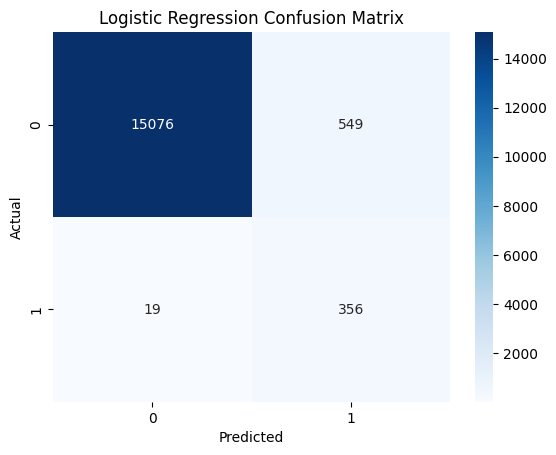

In [ ]:
# Visualization of the confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

Model 2: Decision Tree

Best Parameters (F1 Model):  {'class_weight': None, 'max_depth': 10, 'min_samples_leaf': 5}
Accuracy:  0.9885625
Confusion Matrix:
 [[15591    34]
 [  149   226]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99     15625
           1       0.87      0.60      0.71       375

    accuracy                           0.99     16000
   macro avg       0.93      0.80      0.85     16000
weighted avg       0.99      0.99      0.99     16000



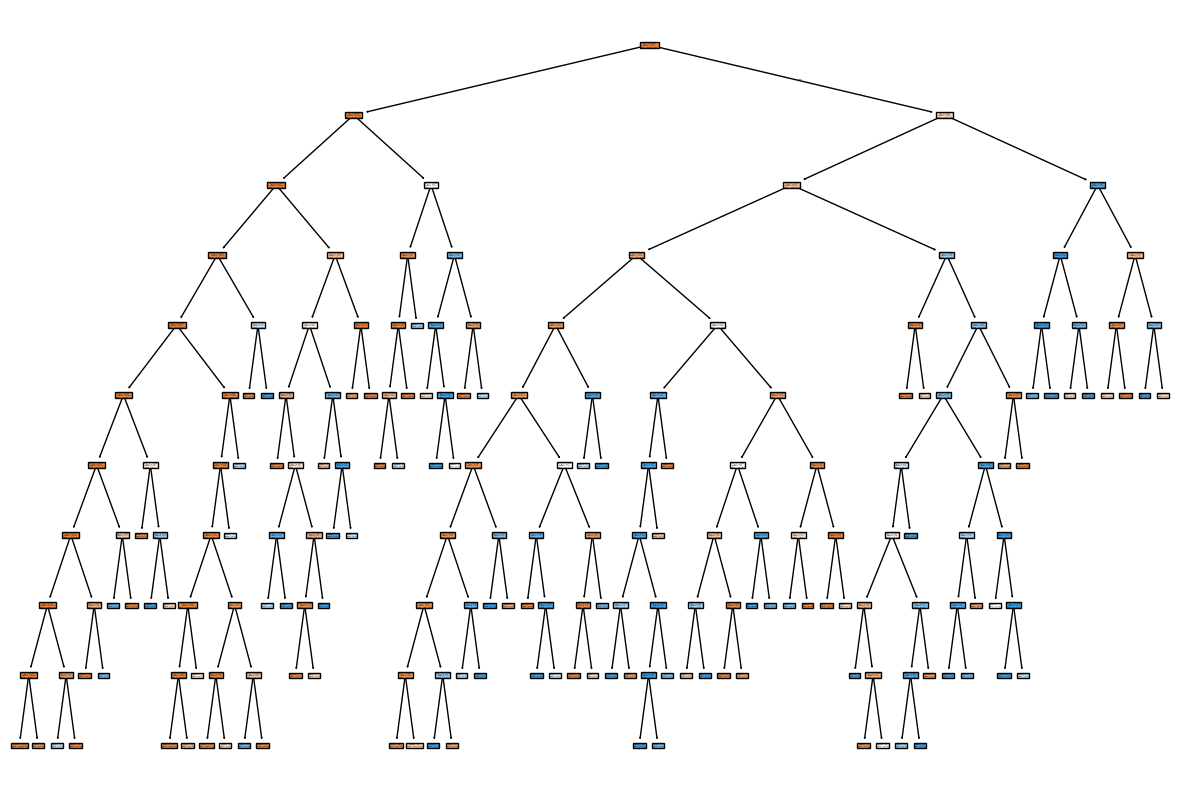

In [ ]:
# Hyperparameter tree for Decision Tree
param_grid = {
    'max_depth': [5, 10, 15, None],
    'min_samples_leaf': [5, 10, 20],
    'class_weight': [None, 'balanced']
}

# GridSearchCV to find the best hyperparameters
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Train the model across all hyperparameter combinations
grid_dt.fit(x_train, y_train)

# Find the best model based on F1 score
best_df_f1 = grid_dt.best_estimator_
print("Best Parameters (F1 Model): ", grid_dt.best_params_)

# Making predictions on the test dataset
y_pred_dt = best_df_f1.predict(x_test)

# Evaluation results
print('Accuracy: ', accuracy_score(y_test, y_pred_dt))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_dt))
print('Classification Report:\n', classification_report(y_test, y_pred_dt))

# Visualization of the decision tree structure
plt.figure(figsize=(15,10))
plot_tree(best_df_f1, filled=True)
plt.show()

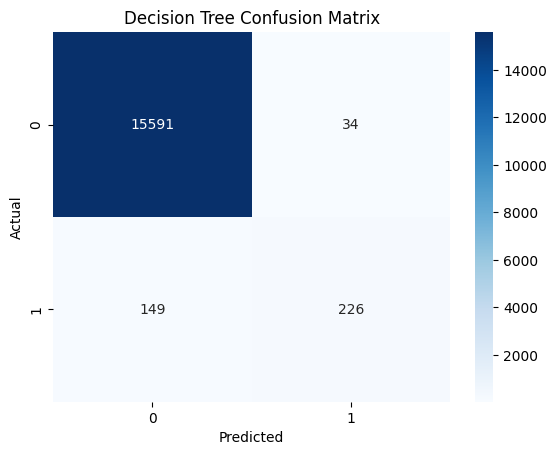

In [ ]:
# Visualization of the confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Model 3: K-Nearest Neighbor

In [ ]:
# Initialize the KNN model
knn_model = KNeighborsClassifier()

In [ ]:
# 5-fold cross-validation on training data
scores = cross_val_score(knn_model, x_train_scaled, y_train, cv=5, scoring='accuracy')

In [ ]:
print(scores)

[0.99116667 0.99108333 0.98958333 0.98925    0.99083333]


In [ ]:
print(scores.mean())

0.9903833333333335


In [ ]:
# Train the KNN model on the full training dataset
knn_model.fit(x_train_scaled, y_train)

KNeighborsClassifier()

In [ ]:
# Make predictions on the test dataset
knn_predict = knn_model.predict(x_test_scaled)

In [ ]:
# Evaluate model performance
print('Accuracy: ', accuracy_score(y_test, knn_predict))
print('Confusion Matrix:\n', confusion_matrix(y_test, knn_predict))
print('Classification Report:\n', classification_report(y_test, knn_predict))

Accuracy:  0.988
Confusion Matrix:
 [[15595    30]
 [  162   213]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99     15625
           1       0.88      0.57      0.69       375

    accuracy                           0.99     16000
   macro avg       0.93      0.78      0.84     16000
weighted avg       0.99      0.99      0.99     16000



CONFUSION MATRIX

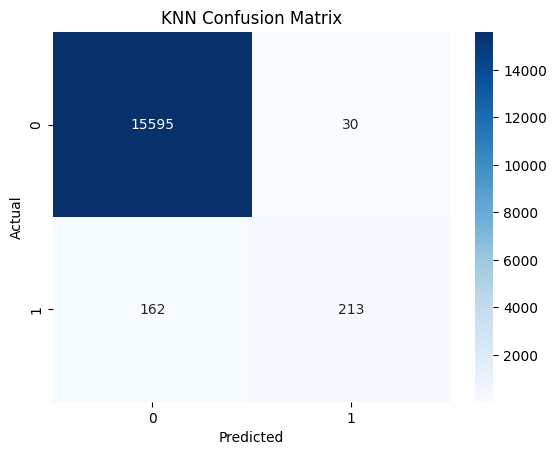

In [ ]:
# Visualization of the confusion matrix
sns.heatmap(confusion_matrix(y_test, knn_predict), annot=True, fmt='d', cmap='Blues')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

KNN MODEL #2

In [ ]:
# Hyperparameter grid for K-Nearest Neighbors
param_grid = {
    'n_neighbors': [3, 5, 7, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# GridSearchCV to find the best hyperparameters
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Train the model for all hyperparameter combinations
grid_knn.fit(x_train_scaled, y_train)

# Retrieve the best model
best_knn = grid_knn.best_estimator_

print("Best Parameters: ", grid_knn.best_params_)

Best Parameters:  {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}


In [ ]:
# Make predictions on the test dataset
y_pred_knn = best_knn.predict(x_test_scaled)

# Evaluation results
print('Accuracy: ', accuracy_score(y_test, y_pred_knn))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_knn))
print('Classification Report:\n', classification_report(y_test, y_pred_knn))

Accuracy:  0.9908125
Confusion Matrix:
 [[15601    24]
 [  123   252]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00     15625
           1       0.91      0.67      0.77       375

    accuracy                           0.99     16000
   macro avg       0.95      0.84      0.88     16000
weighted avg       0.99      0.99      0.99     16000



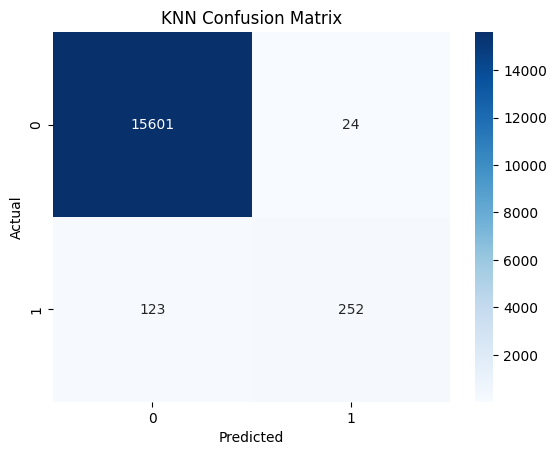

In [ ]:
# Visualization of the confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Blues')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Model 4: SVM

In [ ]:
# Hyperparameter grid for Support Vector Machine (SVM)
param_grid = {
    'C': [1, 10],
    'gamma': ['scale', 0.1],
    'kernel': ['rbf']
}

# GridSearchCV to find the best SVM model
grid_svm = GridSearchCV(
    SVC(class_weight='balanced'),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

# Train the model on the hyperparameter combinatiosn
grid_svm.fit(x_train_scaled, y_train)

# Find the best SVM model
best_svm = grid_svm.best_estimator_

print("Best Parameters: ", grid_svm.best_params_)

# Make rpediction son the test dataset
svm_pred = best_svm.predict(x_test_scaled)

# Evaluation results
print('Accuracy: ', accuracy_score(y_test, svm_pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, svm_pred))
print('Classification Report:\n', classification_report(y_test, svm_pred))

Best Parameters:  {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Accuracy:  0.9906875
Confusion Matrix:
 [[15577    48]
 [  101   274]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00     15625
           1       0.85      0.73      0.79       375

    accuracy                           0.99     16000
   macro avg       0.92      0.86      0.89     16000
weighted avg       0.99      0.99      0.99     16000



In [ ]:
# Reduce features to 2 principal compoenets for visualization
pca_vis = PCA(n_components=2)

# Fit PCA on training data and transform both train and test sets
x_train_pca = pca_vis.fit_transform(x_train_scaled)
x_test_pca = pca_vis.transform(x_test_scaled)

In [ ]:
# Use best hyperparameters found in the GridSearch
smv_vis = SVC(
    kernel='rbf',
    C=grid_svm.best_params_['C'],
    gamma=grid_svm.best_params_['gamma'],
    class_weight='balanced'
)

# Train SVM on reduced 2D data
smv_vis.fit(x_train_pca, y_train)

SVC(C=10, class_weight='balanced')

In [ ]:
def plot_decision_boundary(model, X, y):
  """
  Visualizes the decision voundary of a trained classification model
  in a 2F feature space.

  Creates a mesh grid over the feature space, uses the model to predict
  class labels for each point int eh grid, and then plots the resulting
  decision regions along with the original data points.

  Parameters:
  - model: A trained classificaiton model. The model must accept a 2D array
  - X: Feature matrix. Must contain exactly two features.
  - y: Target labels. Used for coloring the data points in the plot.
  """

  # Define mesh grid boundaries
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

  # Create grid of points
  xx, yy = np.meshgrid(
      np.linspace(x_min, x_max, 200),
      np.linspace(y_min, y_max, 200)
  )

  # Predict over grid and reshape for contour plot
  Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)

  # Plot decision regions and data points
  plt.contourf(xx, yy, Z, cmap="coolwarm", alpha=0.3)
  plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors='k')

  # Plot graph
  plt.xlabel("PCA Component 1")
  plt.ylabel("PCA Component 2")
  plt.title("SVM Decision Boundary (PCA Reduced)")
  plt.show()

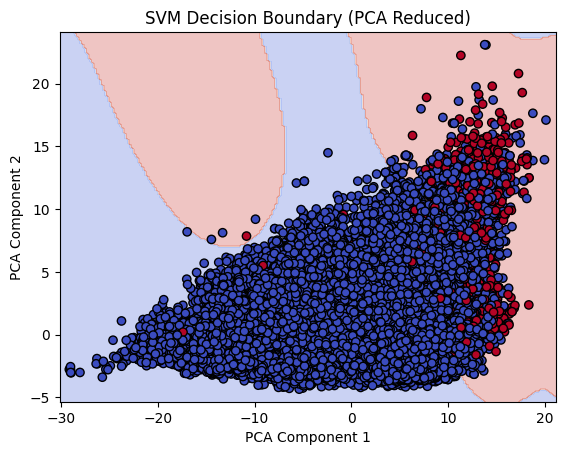

In [ ]:
# Plot decision boundary
plot_decision_boundary(smv_vis, x_train_pca, y_train)

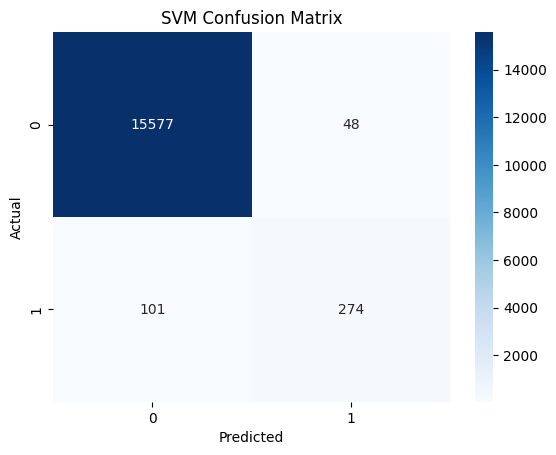

In [ ]:
# Visualization of the confusion matrix
sns.heatmap(confusion_matrix(y_test, svm_pred), annot=True, fmt='d', cmap='Blues')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Model #5: Random Forest

In [ ]:
# Baseline Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight=None,
    random_state=42,
    n_jobs=-1
)

# Train and evaluate baseline Random Forest
rf_model.fit(x_train, y_train)
rf_pred = rf_model.predict(x_test)

print("Baseline Random Forest")
# Evaluation results
print('Accuracy: ', accuracy_score(y_test, rf_pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, rf_pred))
print('Classification Report:\n', classification_report(y_test, rf_pred))

Tuned Random Forest
Accuracy:  0.992125
Confusion Matrix:
 [[15608    17]
 [  109   266]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00     15625
           1       0.94      0.71      0.81       375

    accuracy                           0.99     16000
   macro avg       0.97      0.85      0.90     16000
weighted avg       0.99      0.99      0.99     16000



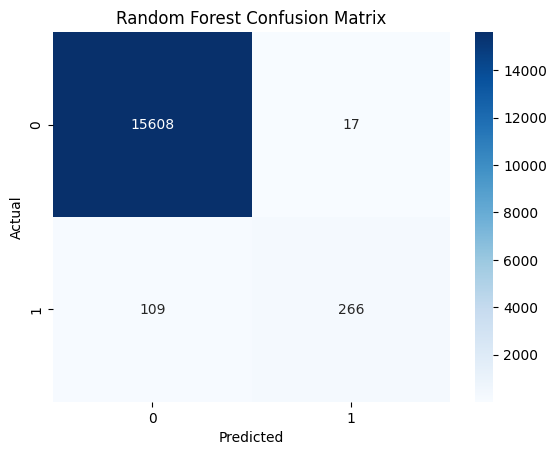

In [ ]:
# Visualization of the confusion matrix
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

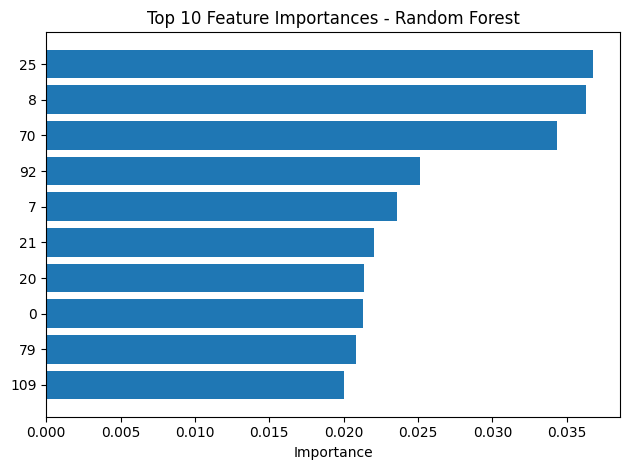

In [ ]:
# Extract and plot top 10 most important features
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.barh(range(len(indices)), importances[indices])

plt.yticks(range(len(indices)), indices)
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

Tuned Random Forest

In [ ]:
# Hyperparameter tuning for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': [None, 'balanced']
}

# Grid Search to find the best model
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Fit the model on the training data
grid_rf.fit(x_train, y_train)

# Best tuned model
best_rf = grid_rf.best_estimator_

# Make predictions on the test dataset
y_pred_rf = best_rf.predict(x_test)

print("Tuned Random Forest")

# Evaluation results
print('Accuracy: ', accuracy_score(y_test, y_pred_rf))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_rf))
print('Classification Report:\n', classification_report(y_test, y_pred_rf))

KeyboardInterrupt: 

Model 6: XGBoost

In [ ]:
# Handle class imbalance using scale_pos_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

In [ ]:
# XGB model using the best parameters
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

In [ ]:
# Train the model
xgb_model.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:22:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Make predictions on the test dataset
y_pred_xgb = xgb_model.predict(x_test)

In [ ]:
# Evaluation results
print("XGBoost Results")
print('Accuracy: ', accuracy_score(y_test, y_pred_xgb))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_xgb))
print('Classification Report:\n', classification_report(y_test, y_pred_xgb))

XGBoost Results
Accuracy:  0.9935
Confusion Matrix:
 [[15578    47]
 [   57   318]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     15625
           1       0.87      0.85      0.86       375

    accuracy                           0.99     16000
   macro avg       0.93      0.92      0.93     16000
weighted avg       0.99      0.99      0.99     16000



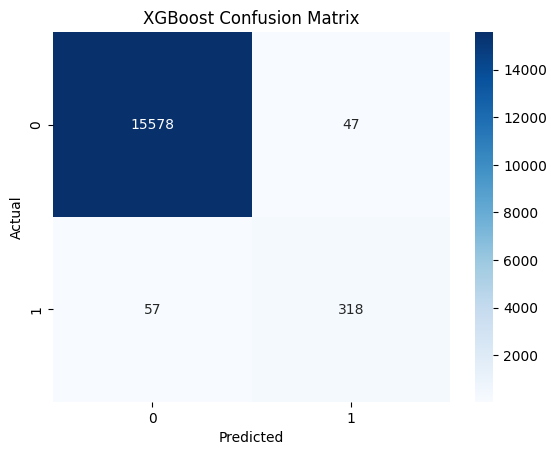

In [ ]:
# Visualization of the confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Blues')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

<Figure size 1000x600 with 0 Axes>

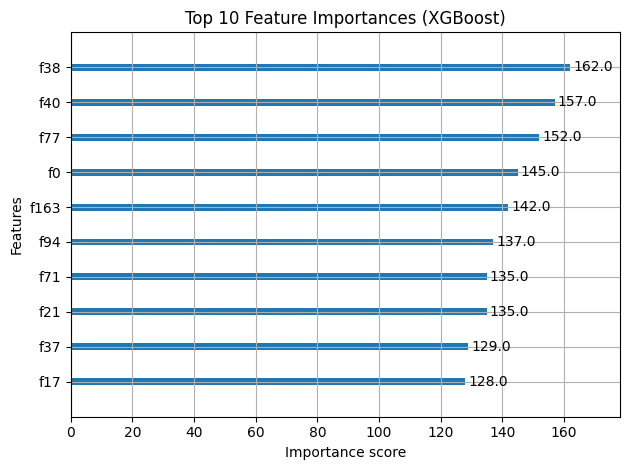

In [ ]:
# XGBoost feature important
from xgboost import plot_importance
plt.figure(figsize=(10,6))
plot_importance(xgb_model, max_num_features=10)
plt.title("Top 10 Feature Importances (XGBoost)")
plt.tight_layout()
plt.show()

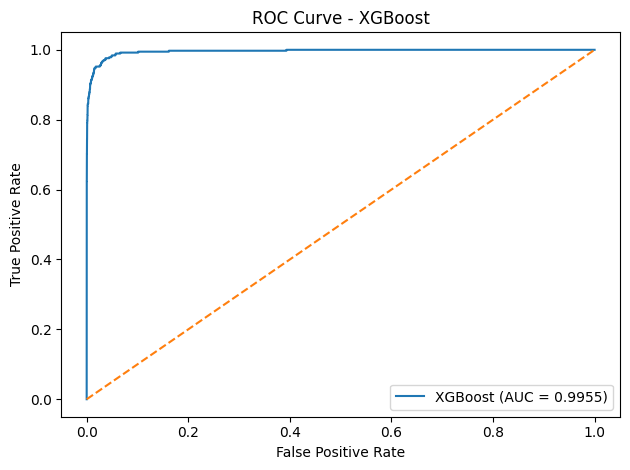

In [ ]:
# ROC Cruve for XGBoost
y_prob_xgb = xgb_model.predict_proba(x_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.tight_layout()
plt.show()

Results Table

In [ ]:
results = []

def add_results(name, model, X_train, X_test, y_train, y_test):
  """
  Trains a mdoel, makes predictions, evaluates performance,
  and stores the results in a list.

  Parameters:
  - name: String label for the model
  - model: Machine learning model object
  - X_train, X_test: Feature datasets for training and testing
  - y_train, y_test: Target labels for training and testing
  """

  # Train the model using training data
  model.fit(X_train, y_train)

  # Make predictions on both training and testing datsets
  y_train_pred = model.predict(X_train)
  y_test_pred = model.predict(X_test)

  # Store the evaluation metrics for both training and testing
  results.append({
      "Model": name,
      # Training metrics
      "Train Accuracy": accuracy_score(y_train, y_train_pred),
      "Train Precision": precision_score(y_train, y_train_pred),
      "Train Recall": recall_score(y_train, y_train_pred),
      "Train F1": f1_score(y_train, y_train_pred),

      # Testing metrics
      "Test Accuracy": accuracy_score(y_test, y_test_pred),
      "Test Precision": precision_score(y_test, y_test_pred),
      "Test Recall": recall_score(y_test, y_test_pred),
      "Test F1": f1_score(y_test, y_test_pred)
  })

# Logistic Regression
add_results("Logistic Regression", LogisticRegression(
    C=0.1, max_iter=1000, class_weight='balanced'),
    x_train_scaled, x_test_scaled, y_train, y_test)

# Decision Tree
add_results("Decision Tree", DecisionTreeClassifier(
    max_depth=10, min_samples_leaf=5, random_state=42),
            x_train, x_test, y_train, y_test)

# KNN
add_results("KNN", KNeighborsClassifier(
    n_neighbors=3, weights='distance', metric='manhattan'),
    x_train_scaled, x_test_scaled, y_train, y_test)

# SVM
add_results("SVM", SVC(C=10, gamma='scale', kernel='rbf', class_weight='balanced'),
            x_train_scaled, x_test_scaled, y_train, y_test)

# Random Forest
add_results("Random Forest", RandomForestClassifier(
    n_estimators=200, max_depth=None, min_samples_split=2,
    min_samples_leaf=1, random_state=42, n_jobs=-1),
            x_train, x_test, y_train, y_test)

# XGBoost
add_results("XGBoost", XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                     subsample=0.8, colsample_bytree=0.8, scale_pos_weight=59,
                                     random_state=42, eval_metric='logloss'),
            x_train, x_test, y_train, y_test)

# Convert to pandas DataFrame and sort by F1-score
results_df = pd.DataFrame(results).sort_values("Test F1", ascending=False)
print(results_df.to_string(index=False))


              Model  Train Accuracy  Train Precision  Train Recall  Train F1  Test Accuracy  Test Precision  Test Recall  Test F1
            XGBoost        0.999850         0.991080         1.000  0.995520       0.993500        0.871233     0.848000 0.859459
      Random Forest        1.000000         1.000000         1.000  1.000000       0.992125        0.939929     0.709333 0.808511
                SVM        0.998017         0.894360         0.999  0.943788       0.990688        0.850932     0.730667 0.786227
                KNN        1.000000         1.000000         1.000  1.000000       0.990812        0.913043     0.672000 0.774194
      Decision Tree        0.995333         0.947761         0.762  0.844789       0.988563        0.869231     0.602667 0.711811
Logistic Regression        0.962933         0.306206         0.967  0.465127       0.964063        0.390830     0.954667 0.554609


Finals Charts/Grahps

1. Model Comparison Bar Chart

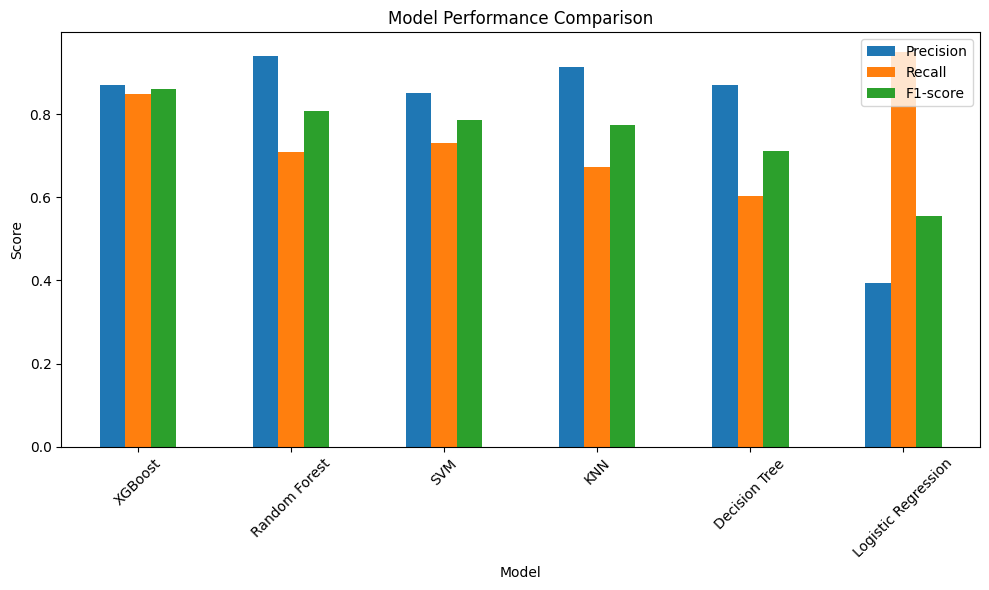

In [ ]:
# Visuzaliation of precision, recall, and F1-score for all models
metrics_df = results_df.set_index("Model")

metrics_df[['Precision', 'Recall', 'F1-score']].plot(kind='bar', figsize=(10,6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

2. Recall-Focused Chart

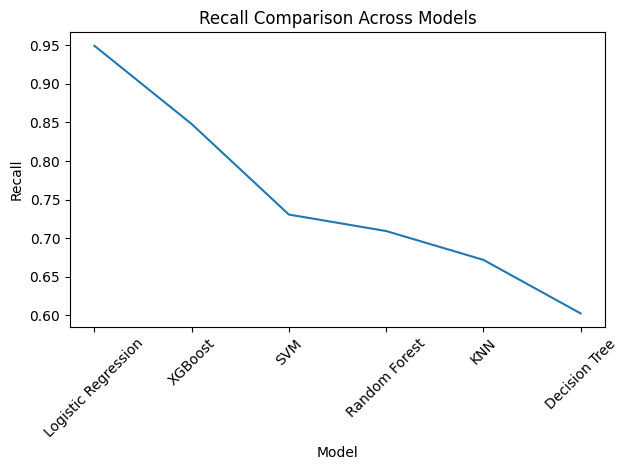

In [ ]:
# Visualization of the recall scores for all models
results_df.sort_values(by='Recall', ascending=False).plot(
    x="Model", y="Recall", legend=False
)

plt.title("Recall Comparison Across Models")
plt.ylabel("Recall")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

3. F1 Comparison Chart

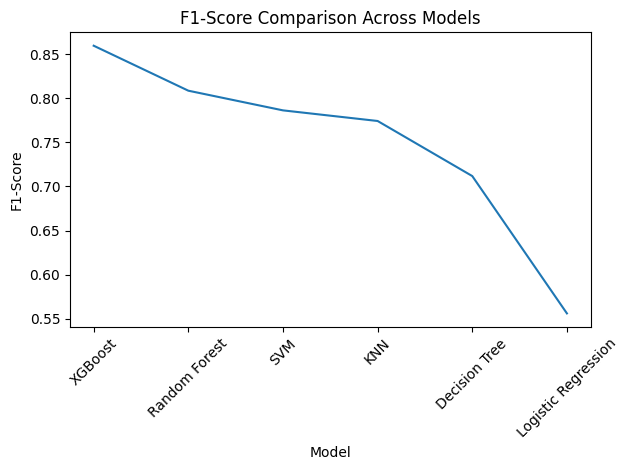

In [ ]:
# Visualization of F1-score for all models
results_df.sort_values(by='F1-score', ascending=False).plot(
    x="Model", y="F1-score", legend=False
)

plt.title("F1-Score Comparison Across Models")
plt.ylabel("F1-Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()